In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import csv 
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import ConfusionMatrixDisplay
import umap
from plotting import save_plot_scatter, save_confusion_matrix

/local/s4099699/IDL/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
# Load data
X = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/train_in - Copy.csv', delimiter=',')
y = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/train_out - Copy.csv', delimiter=',').ravel().astype(int)
X_test = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/test_in - Copy.csv', delimiter=',')
y_test = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/test_out - Copy.csv', delimiter=',').astype(int)


### Task 1.1

In [8]:
unique_labels = np.unique(y)
means = np.array([X[y == label].mean(axis=0) for label in unique_labels])

n_labels = unique_labels.shape[0]
dist_matrix = []
for i in range(n_labels):
    dist_row = []
    for j in range(n_labels):
        euclidean_dist = np.linalg.norm(means[i]-means[j])
        dist_row.append(euclidean_dist)
    dist_matrix.append(dist_row)
dist_matrix = np.array(dist_matrix)
np.set_printoptions(precision=2, suppress=True, linewidth=100) # Comment out to print normally
print(dist_matrix) # Uncomment to check matrix

[[ 0.   14.45  9.33  9.14 10.77  7.52  8.15 11.86  9.91 11.49]
 [14.45  0.   10.13 11.73 10.17 11.12 10.61 10.74 10.09  9.93]
 [ 9.33 10.13  0.    8.18  7.93  7.91  7.33  8.87  7.08  8.89]
 [ 9.14 11.73  8.18  0.    9.09  6.12  9.3   8.92  7.02  8.35]
 [10.77 10.17  7.93  9.09  0.    8.    8.78  7.58  7.38  6.01]
 [ 7.52 11.12  7.91  6.12  8.    0.    6.7   9.21  6.97  8.26]
 [ 8.15 10.61  7.33  9.3   8.78  6.7   0.   10.89  8.59 10.44]
 [11.86 10.74  8.87  8.92  7.58  9.21 10.89  0.    8.47  5.43]
 [ 9.91 10.09  7.08  7.02  7.38  6.97  8.59  8.47  0.    6.4 ]
 [11.49  9.93  8.89  8.35  6.01  8.26 10.44  5.43  6.4   0.  ]]


### Task 1.2

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(X_pca.shape)
plot_scatter(X_pca, y, "pca_plot.png")

X_tsne = TSNE(n_components=2).fit_transform(X)
print(X_tsne.shape)
plot_scatter(X_tsne, y, "tsne_plot.png")

reducer = umap.UMAP()
X_umap = reducer.fit_transform(X)
print(X_umap.shape)
plot_scatter(X_umap, y, "umap_plot.png")

# plot PCA centres
X_pca_centres = pca.fit_transform(means)
plot_scatter(X_pca_centres, unique_labels, "pca_centres_plot.png")

### Task 1.3

In [9]:
def centre_predictions(string, X, y):
    """
    uses euclidean distance from label means to predict class
    """
    predictions = []
    losses = []
    for idx, x_i in enumerate(X):
        x_i_broadcasted = np.broadcast_to(x_i, means.shape)
        dist = np.linalg.norm(x_i_broadcasted-means, axis=1)
        pred_y = np.argmin(dist)
        loss = 1 if pred_y == y[idx] else 0
        predictions.append(pred_y)
        losses.append(loss)

    percentage_true_pred = np.sum(losses) / len(losses)
    print (string, f"Percentage of true predictions: {percentage_true_pred:.4f}")

    return predictions, losses

train_centre_pred, _ = centre_predictions("(train)",X, y)

test_centre_pred, _ = centre_predictions("(test)", X_test, y_test)

(train) Percentage of true predictions: 0.8635
(test) Percentage of true predictions: 0.8040


### Task 1.4

In [11]:
neigh = KNeighborsClassifier()
neigh.fit(X,y)

train_pred, test_pred = neigh.predict(X), neigh.predict(X_test)

print(X.shape, train_pred.shape)
train_loss_arr = np.where(train_pred == y, 1, 0)
test_loss_arr = np.where(test_pred == y_test, 1, 0)

def print_pred_perc(string, losses):
    percentage_true_pred = np.sum(losses) / len(losses)
    print (string, f"Percentage of true predictions: {percentage_true_pred:.4f}")

print_pred_perc("(train)", train_loss_arr)
print_pred_perc("(test)", test_loss_arr)

# Confusion matrices

print("Shapes:", len(train_centre_pred), y.shape)

save_confusion_matrix(train_centre_pred, y, "cm_centre_pred_train.png", "Confusion Matrix: using train label centres (train).")
save_confusion_matrix(test_centre_pred, y_test, "cm_centre_pred_test.png", "Confusion Matrix: using train label centres (test).")
save_confusion_matrix(train_pred, y, "cm_knn_pred_train.png", "Confusion Matrix: using knn with train labels (train).")
save_confusion_matrix(test_pred, y_test, "cm_knn_pred_test.png", "Confusion Matrix: using knn with train labels (test).")

(1707, 256) (1707,)
(train) Percentage of true predictions: 0.9660
(test) Percentage of true predictions: 0.9080
Shapes: 1707 (1707,)


## Task 2

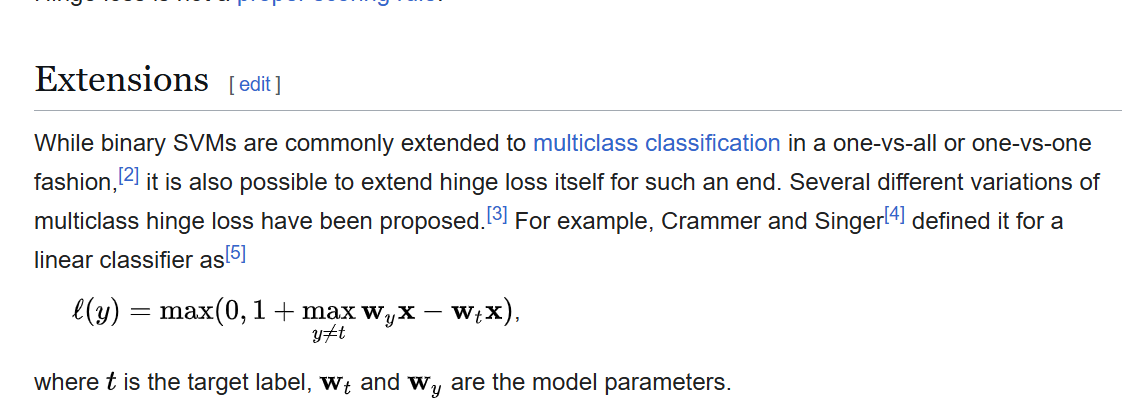

In [42]:
seed = np.random.seed(111)
lr = 0.01
n_epochs = 100

X_in = X.T 
in_dim = X_in.shape[0]
n_samples = X_in.shape[1]
bias = np.ones((1, n_samples))
T = np.vstack((bias, X_in))
out_dim = 10
variance_W = 4 / (in_dim + out_dim)
W = np.hstack((np.zeros((out_dim, 1)), np.random.normal(0, variance_W, (out_dim, in_dim))))

loss = []

for i in range(n_epochs):
    f = W @ T #logit outputs
    f_max = np.max(f, axis=0)
    exp_f = np.exp(f - f_max) # prevent overflow
    log_sum_exp = f_max + np.log(np.sum(exp_f, axis=0)) # factor out the fmax from f_i - fmax in the sum iteration 
    target_logits = f[y, np.arange(f.shape[1])]
    L = -np.sum(target_logits - log_sum_exp) #mutliclass cross entropy loss computation

    loss.append(L)
    print(f"Epoch {i+1} | Avg loss: {L / n_samples:.6f}")

    prob = exp_f / np.sum(exp_f, axis=0)
    prob[y, np.arange(f.shape[1])] -= 1.0
    dW = prob @ T.T
    W = W - lr*dW

T = np.vstack((np.ones((1, y_test.shape[0])), X_test.T))
predictions = np.argmax(W @ T, axis=0)

f = W @ T #logit outputs
f_max = np.max(f, axis=0)
exp_f = np.exp(f - f_max) # prevent overflow
log_sum_exp = f_max + np.log(np.sum(exp_f, axis=0)) # factor out the fmax from f_i - fmax in the sum iteration 
target_logits = f[y_test, np.arange(f.shape[1])]
L = -np.sum(target_logits - log_sum_exp) #mutliclass cross entropy loss computation
accuracy = np.sum((predictions == y_test).astype(int))/y_test.shape[0]
print(f"(Test) | Avg loss: {L / n_samples:.6f}| Accuracy: {accuracy:.6f}")
 



Epoch 1 | Avg loss: 2.263932
Epoch 2 | Avg loss: 70.316148
Epoch 3 | Avg loss: 173.543382
Epoch 4 | Avg loss: 171.967180
Epoch 5 | Avg loss: 116.004607
Epoch 6 | Avg loss: 85.325428
Epoch 7 | Avg loss: 63.461822
Epoch 8 | Avg loss: 54.593642
Epoch 9 | Avg loss: 34.808195
Epoch 10 | Avg loss: 20.065479
Epoch 11 | Avg loss: 7.398554
Epoch 12 | Avg loss: 6.342522
Epoch 13 | Avg loss: 5.997096
Epoch 14 | Avg loss: 4.915170
Epoch 15 | Avg loss: 4.014889
Epoch 16 | Avg loss: 3.364057
Epoch 17 | Avg loss: 2.807066
Epoch 18 | Avg loss: 2.328721
Epoch 19 | Avg loss: 2.045853
Epoch 20 | Avg loss: 1.889581
Epoch 21 | Avg loss: 1.752348
Epoch 22 | Avg loss: 1.621224
Epoch 23 | Avg loss: 1.537332
Epoch 24 | Avg loss: 1.465422
Epoch 25 | Avg loss: 1.430935
Epoch 26 | Avg loss: 1.348845
Epoch 27 | Avg loss: 1.317587
Epoch 28 | Avg loss: 1.225835
Epoch 29 | Avg loss: 1.183872
Epoch 30 | Avg loss: 1.117628
Epoch 31 | Avg loss: 1.064427
Epoch 32 | Avg loss: 1.017575
Epoch 33 | Avg loss: 0.976692
Epoch 3

In [39]:
y_test.shape

(1000,)

In [23]:
prob

NameError: name 'prob' is not defined

In [22]:
f_max

array([[0.32479564, 0.28858313, 0.32085901, ..., 0.27060625, 0.07764201,
        0.16316173]], shape=(1, 1707))

In [14]:
target_logits = f[y.astype(int), np.arange(f.shape[1])]

In [15]:
target_logits

array([-0.01810218, -0.35088227, -0.13141933, ..., -0.37869136,
        0.07764201,  0.0815978 ], shape=(1707,))

In [110]:
y.size

1707

In [122]:
y_binary = -np.ones((out_dim, y.size), dtype=np.int8)
# y_binary[np.arange(y.size), y] = 1
y_binary[y.astype(int), np.arange(y.size)] = 1
y_binary

array([[-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       ...,
       [-1, -1, -1, ...,  1, -1, -1],
       [-1, -1, -1, ..., -1, -1,  1],
       [-1, -1, -1, ..., -1,  1, -1]], shape=(10, 1707), dtype=int8)

In [ ]:

np.full(10, -1)

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [71]:
a = np.array([1,2,1])
np.tile(a, (3,1))

array([[1, 2, 1],
       [1, 2, 1],
       [1, 2, 1]])